# Public Bus Route Efficiency Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/home/jawad/Downloads/bus_routes.csv")
df

,Trip_ID,Bus_ID,Route,Driver,Distance_km,Fuel_Used_L,Passengers,Delay_Minutes,Ticket_Price
0,1001,B101,R1,Ali,120,18,45,5,150
1,1002,B102,R2,Sara,90,14,38,10,120
2,1003,B103,R3,Ahmed,150,22,60,0,180
3,1004,B101,R1,Ayesha,110,17,42,8,150
4,1005,B104,R4,Zain,80,13,30,15,100
5,1006,B105,R2,Hina,95,15,40,12,120
6,1007,B103,R3,Usman,140,21,58,3,180
7,1008,B102,R2,Maria,100,16,36,7,120
8,1009,B104,R4,Hassan,85,14,32,18,100
9,1010,B105,R1,Fatima,130,19,50,4,150


In [4]:
# Calculate the revenue for each trip.
revenue = df["Passengers"] * df["Ticket_Price"]
print("revenue of each trip : ",revenue)
print("\n")
# Calculate fuel efficiency.
fuel_efficiency = df["Distance_km"] / df["Fuel_Used_L"]
print("fuel_efficiency : ",fuel_efficiency)

revenue of each trip :  0      6750
1      4560
2     10800
3      6300
4      3000
5      4800
6     10440
7      4320
8      3200
9      7500
10     9900
11     2800
12     5520
13     7800
14    11700
15     5280
16     7200
17     3100
18    10620
19     5160
dtype: int64


fuel_efficiency :  0     6.666667
1     6.428571
2     6.818182
3     6.470588
4     6.153846
5     6.333333
6     6.666667
7     6.250000
8     6.071429
9     6.842105
10    7.250000
11    6.250000
12    6.562500
13    6.944444
14    6.739130
15    6.533333
16    6.941176
17    6.307692
18    6.727273
19    6.375000
dtype: float64


In [5]:
# Total revenue
total_revenue = np.sum(revenue)
print("total_revenue : ",total_revenue)
# average revenue
average_revenue = np.mean(revenue)
print("average revenue : ",average_revenue)
# highest revenue
highest_revenue = np.max(revenue)
print("highest revenue : ",highest_revenue)
# lowest revenue 
lowest_revenue = np.min(revenue)
print("lowest revenue : ",lowest_revenue)

total_revenue :  130750
average revenue :  6537.5
highest revenue :  11700
lowest revenue :  2800


In [6]:
# Find the bus with the highest fuel efficiency.
index = np.argmax(fuel_efficiency)
print(df["Bus_ID"][index])
# Count trips where      ,  Delay > 10 minutes      ,Passengers > 50
count_trips = count = ((df["Delay_Minutes"] > 10) & (df["Passengers"] > 50)).sum()
print(count_trips)



B101
0


In [7]:
# Find:
# Mean distance
# Median passengers
# Standard deviation of delays

mean_distance = np.mean(df["Distance_km"])
print("mean distance : ",mean_distance)
median_passengers = np.median(df["Passengers"])
print("median passengers : ",median_passengers)
standard_deviation = np.std(df["Delay_Minutes"])
print("standard deviation of delays : ",standard_deviation)

mean distance :  112.65
median passengers :  44.5
standard deviation of delays :  5.90846849868898


In [8]:
# Normalize the passenger counts.
passenger = df["Passengers"]
min_passenger = np.min(passenger)
max_passenge = np.max(passenger)
normalized = (passenger - min_passenger)/(max_passenge - min_passenger)
print("normalized passenger counts : ",normalized.round())

normalized passenger counts :  0     0.0
1     0.0
2     1.0
3     0.0
4     0.0
5     0.0
6     1.0
7     0.0
8     0.0
9     1.0
10    1.0
11    0.0
12    0.0
13    1.0
14    1.0
15    0.0
16    1.0
17    0.0
18    1.0
19    0.0
Name: Passengers, dtype: float64


In [9]:
# Find the top 5 trips with the highest revenue.
df["Revenue"] = df["Passengers"] * df["Ticket_Price"]
top_five = df.sort_values(by="Revenue",ascending=False).head(5)
print(top_five[["Trip_ID", "Bus_ID", "Route", "Revenue"]])
df


    Trip_ID Bus_ID Route  Revenue
14     1015   B105    R3    11700
2      1003   B103    R3    10800
18     1019   B104    R3    10620
6      1007   B103    R3    10440
10     1011   B101    R3     9900


,Trip_ID,Bus_ID,Route,Driver,Distance_km,Fuel_Used_L,Passengers,Delay_Minutes,Ticket_Price,Revenue
0,1001,B101,R1,Ali,120,18,45,5,150,6750
1,1002,B102,R2,Sara,90,14,38,10,120,4560
2,1003,B103,R3,Ahmed,150,22,60,0,180,10800
3,1004,B101,R1,Ayesha,110,17,42,8,150,6300
4,1005,B104,R4,Zain,80,13,30,15,100,3000
5,1006,B105,R2,Hina,95,15,40,12,120,4800
6,1007,B103,R3,Usman,140,21,58,3,180,10440
7,1008,B102,R2,Maria,100,16,36,7,120,4320
8,1009,B104,R4,Hassan,85,14,32,18,100,3200
9,1010,B105,R1,Fatima,130,19,50,4,150,7500


In [10]:
# Create new columns
# Revenue
# Fuel_Efficiency
df["fuel_efficiency"] = df["Distance_km"] / df["Fuel_Used_L"]
df

,Trip_ID,Bus_ID,Route,Driver,Distance_km,Fuel_Used_L,Passengers,Delay_Minutes,Ticket_Price,Revenue,fuel_efficiency
0,1001,B101,R1,Ali,120,18,45,5,150,6750,6.666667
1,1002,B102,R2,Sara,90,14,38,10,120,4560,6.428571
2,1003,B103,R3,Ahmed,150,22,60,0,180,10800,6.818182
3,1004,B101,R1,Ayesha,110,17,42,8,150,6300,6.470588
4,1005,B104,R4,Zain,80,13,30,15,100,3000,6.153846
5,1006,B105,R2,Hina,95,15,40,12,120,4800,6.333333
6,1007,B103,R3,Usman,140,21,58,3,180,10440,6.666667
7,1008,B102,R2,Maria,100,16,36,7,120,4320,6.250000
8,1009,B104,R4,Hassan,85,14,32,18,100,3200,6.071429
9,1010,B105,R1,Fatima,130,19,50,4,150,7500,6.842105


In [11]:
# Which route earned the most revenue?
route_earned_most_revenue = df.groupby("Route")["Revenue"].sum()
print(" bus earn most revenue : ",route_earned_most_revenue.idxmax())
# Which driver transported the most passengers?
tran_most_pass = df.groupby("Driver")["Passengers"].sum()
print("Driver transport more passengers : ",tran_most_pass.idxmax())
# Which bus completed the longest total distance?
longest_total_dis = df.groupby("Bus_ID")["Distance_km"].sum()
print("bus completed longest distance : ",longest_total_dis.idxmax())
# Which route has the highest average delay?
route_high_delay = df.groupby("Route")["Delay_Minutes"].mean()
print("route high delay : ",route_high_delay.idxmax())
# Which driver has the best average fuel efficiency?
driver_fuel_efficiency = df.groupby("Driver")["fuel_efficiency"].mean()
print("driver with best average fuel efficiency : ",driver_fuel_efficiency.idxmax())
print("\n")

# Calculate total revenue for each route.
total_route_rev = df.groupby("Route")["Revenue"].sum()
print("total revenue for each route : ", total_route_rev)
print("\n")

# Calculate average passengers for each route.
average_passenger = df.groupby("Route")["Passengers"].mean()
print("average passenger for each route : ", average_passenger)
print("\n")

# Find trips with fuel efficiency above the overall average.
avg = df["fuel_efficiency"].mean()
overall_avg=df.iloc[df["fuel_efficiency"] > avg]
print("fuel efficiency above overall average:\n",overall_avg)

 bus earn most revenue :  R3
Driver transport more passengers :  Laiba
bus completed longest distance :  B105
route high delay :  R4
driver with best average fuel efficiency :  Bilal


total revenue for each route :  Route
R1    35550
R2    29640
R3    53460
R4    12100
Name: Revenue, dtype: int64


average passenger for each route :  Route
R1    47.400000
R2    41.166667
R3    59.400000
R4    30.250000
Name: Passengers, dtype: float64


fuel efficiency above overall average:
     Trip_ID Bus_ID Route  Driver  Distance_km  Fuel_Used_L  Passengers  \
0      1001   B101    R1     Ali          120           18          45   
2      1003   B103    R3   Ahmed          150           22          60   
6      1007   B103    R3   Usman          140           21          58   
9      1010   B105    R1  Fatima          130           19          50   
10     1011   B101    R3   Bilal          145           20          55   
13     1014   B104    R1    Eman          125           18          52   


In [12]:
# Sort trips by Revenue in descending order
sorted_trips = df.sort_values(by="Revenue", ascending=False)

print("Trips sorted by Revenue (Highest to Lowest):")
print(sorted_trips)

Trips sorted by Revenue (Highest to Lowest):
    Trip_ID Bus_ID Route   Driver  Distance_km  Fuel_Used_L  Passengers  \
14     1015   B105    R3    Laiba          155           23          65   
2      1003   B103    R3    Ahmed          150           22          60   
18     1019   B104    R3     Iqra          148           22          59   
6      1007   B103    R3    Usman          140           21          58   
10     1011   B101    R3    Bilal          145           20          55   
13     1014   B104    R1     Eman          125           18          52   
9      1010   B105    R1   Fatima          130           19          50   
16     1017   B102    R1     Amna          118           17          48   
0      1001   B101    R1      Ali          120           18          45   
3      1004   B101    R1   Ayesha          110           17          42   
12     1013   B103    R2    Hamza          105           16          46   
15     1016   B101    R2    Jawad           98         

In [13]:
# Create an Efficiency_Rating column based on fuel efficiency.
def efficiency(fuel_efficiency):
    if fuel_efficiency >= 7.0:
        return "Excellent"
    elif fuel_efficiency >= 6.0:
        return "good"
    elif fuel_efficiency >= 5.0:
        return "average"
    else:
        return "poor"
df["fuel_efficiency_Rating"] = df["fuel_efficiency"].apply(efficiency)
df

,Trip_ID,Bus_ID,Route,Driver,Distance_km,Fuel_Used_L,Passengers,Delay_Minutes,Ticket_Price,Revenue,fuel_efficiency,fuel_efficiency_Rating
0,1001,B101,R1,Ali,120,18,45,5,150,6750,6.666667,good
1,1002,B102,R2,Sara,90,14,38,10,120,4560,6.428571,good
2,1003,B103,R3,Ahmed,150,22,60,0,180,10800,6.818182,good
3,1004,B101,R1,Ayesha,110,17,42,8,150,6300,6.470588,good
4,1005,B104,R4,Zain,80,13,30,15,100,3000,6.153846,good
5,1006,B105,R2,Hina,95,15,40,12,120,4800,6.333333,good
6,1007,B103,R3,Usman,140,21,58,3,180,10440,6.666667,good
7,1008,B102,R2,Maria,100,16,36,7,120,4320,6.250000,good
8,1009,B104,R4,Hassan,85,14,32,18,100,3200,6.071429,good
9,1010,B105,R1,Fatima,130,19,50,4,150,7500,6.842105,good


# visuvalization of data

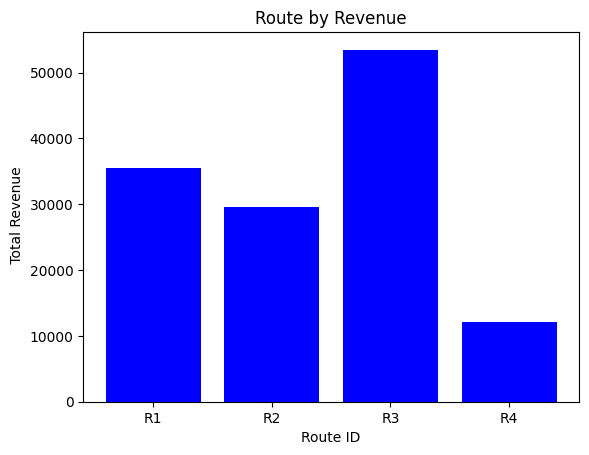

In [30]:
# bar chart
route_revenue = df.groupby("Route")["Revenue"].sum()
plt.Figure(figsize=(8,5))
plt.bar(route_revenue.index,route_revenue.values,color="blue")
plt.title("Route by Revenue")
plt.xlabel("Route ID")
plt.ylabel(" Total Revenue")
plt.show()

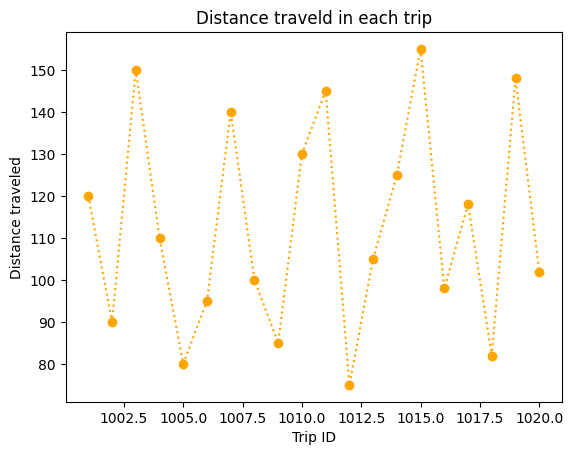

In [37]:
#Distance travelled in each trip
plt.Figure(figsize=(7,5))
plt.plot(df["Trip_ID"],df["Distance_km"],color="orange",marker="o",ls=":")
plt.title("Distance traveld in each trip")
plt.xlabel("Trip ID")
plt.ylabel("Distance traveled")
plt.show()

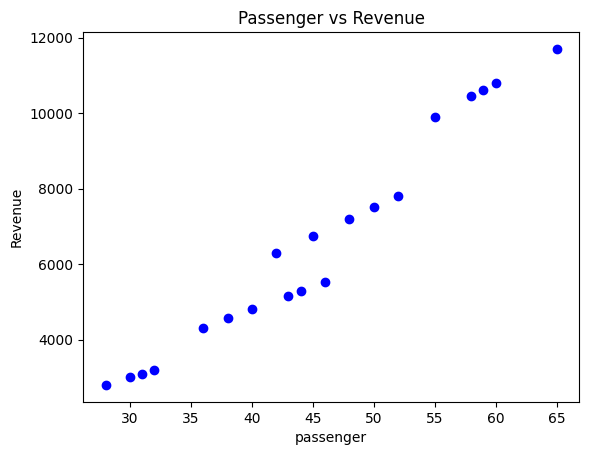

In [46]:
# Scatter Plot
# Passengers vs Revenue
plt.Figure(figsize=(8,5))
plt.scatter(df["Passengers"],df["Revenue"],color="blue",marker="o")
plt.title("Passenger vs Revenue")
plt.xlabel("passenger")
plt.ylabel("Revenue")
plt.show()

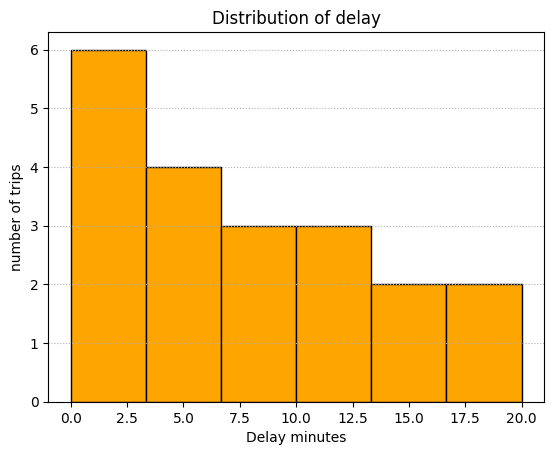

In [58]:
#  Histogram
#Distribution of delays
plt.Figure(figsize=(8,6))
plt.hist(df["Delay_Minutes"],bins=6,edgecolor="black",color="orange")
plt.title("Distribution of delay")
plt.xlabel("Delay minutes")
plt.ylabel("number of trips")
plt.grid(axis="y",ls=":")
plt.show()
